In [1]:
import pandas as pd
import kagglehub
import os


e:\code\datascience\plot\.venv\ml\ML_Prog\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Dataset downloaded to path:", path)
files = os.listdir(path)
print("Files available:", files)
csv_file = [f for f in files if f.endswith('.csv')][0] # Grabs the first CSV found
df = pd.read_csv(os.path.join(path, csv_file))

Dataset downloaded to path: C:\Users\lenovo\.cache\kagglehub\datasets\camnugent\california-housing-prices\versions\1
Files available: ['housing.csv']


In [3]:
import pandas as pd
import numpy as np

In [4]:
def shuffle_split (data,ratio):
    np.random.seed(42)
    shuffled_index = np.random.permutation(len(data))
    test_size = int(len(data)*ratio)
    test_index = shuffled_index[:test_size]
    train_idex = shuffled_index[test_size:]
    return data.iloc[test_index],data.iloc[train_idex]


In [5]:
df['income category'] = pd.cut(df['median_income'],bins = [0,2,5,10,20,np.inf],labels= ['0-2','2-5','5-10','10-20','>20'])

In [6]:
# Shuffle Test Function

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, train_size=.2,random_state=42)


In [8]:
for train_index, test_index in split.split(df,df['income category']):
    train_data = df.loc[train_index]
    test_data = df.loc[test_index]

In [9]:
test_data.drop(columns = 'income category',inplace=True)
train_data.drop(columns = 'income category',inplace=True)


In [10]:
df_train = train_data.copy()
df_test = test_data.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

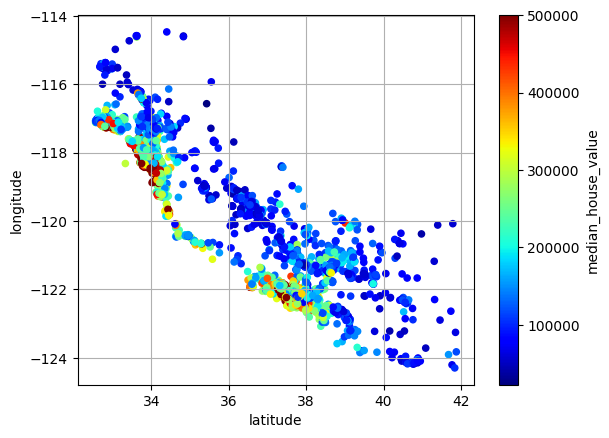

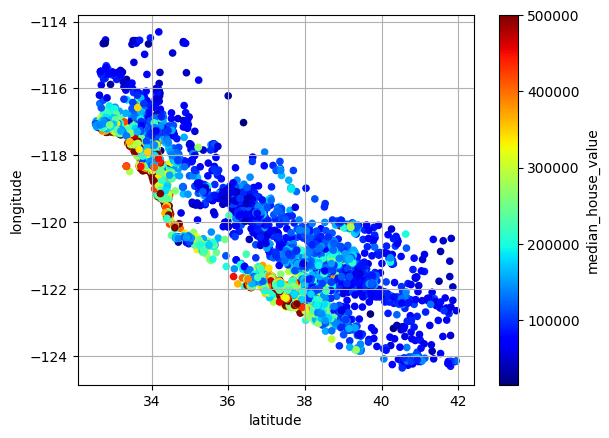

In [11]:
df_train.plot(kind = "scatter",x ="latitude",y = "longitude",grid = True , c ="median_house_value",cmap = 'jet' )
df_test.plot(kind = "scatter",x ="latitude",y = "longitude",grid = True ,  c = 'median_house_value',cmap = 'jet')

In [12]:
#scatter plot for correlation

array([[<Axes: xlabel='longitude', ylabel='longitude'>,
        <Axes: xlabel='latitude', ylabel='longitude'>,
        <Axes: xlabel='housing_median_age', ylabel='longitude'>,
        <Axes: xlabel='total_rooms', ylabel='longitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='longitude'>,
        <Axes: xlabel='population', ylabel='longitude'>,
        <Axes: xlabel='households', ylabel='longitude'>,
        <Axes: xlabel='median_income', ylabel='longitude'>,
        <Axes: xlabel='median_house_value', ylabel='longitude'>],
       [<Axes: xlabel='longitude', ylabel='latitude'>,
        <Axes: xlabel='latitude', ylabel='latitude'>,
        <Axes: xlabel='housing_median_age', ylabel='latitude'>,
        <Axes: xlabel='total_rooms', ylabel='latitude'>,
        <Axes: xlabel='total_bedrooms', ylabel='latitude'>,
        <Axes: xlabel='population', ylabel='latitude'>,
        <Axes: xlabel='households', ylabel='latitude'>,
        <Axes: xlabel='median_income', ylabel='latitude'>,
    

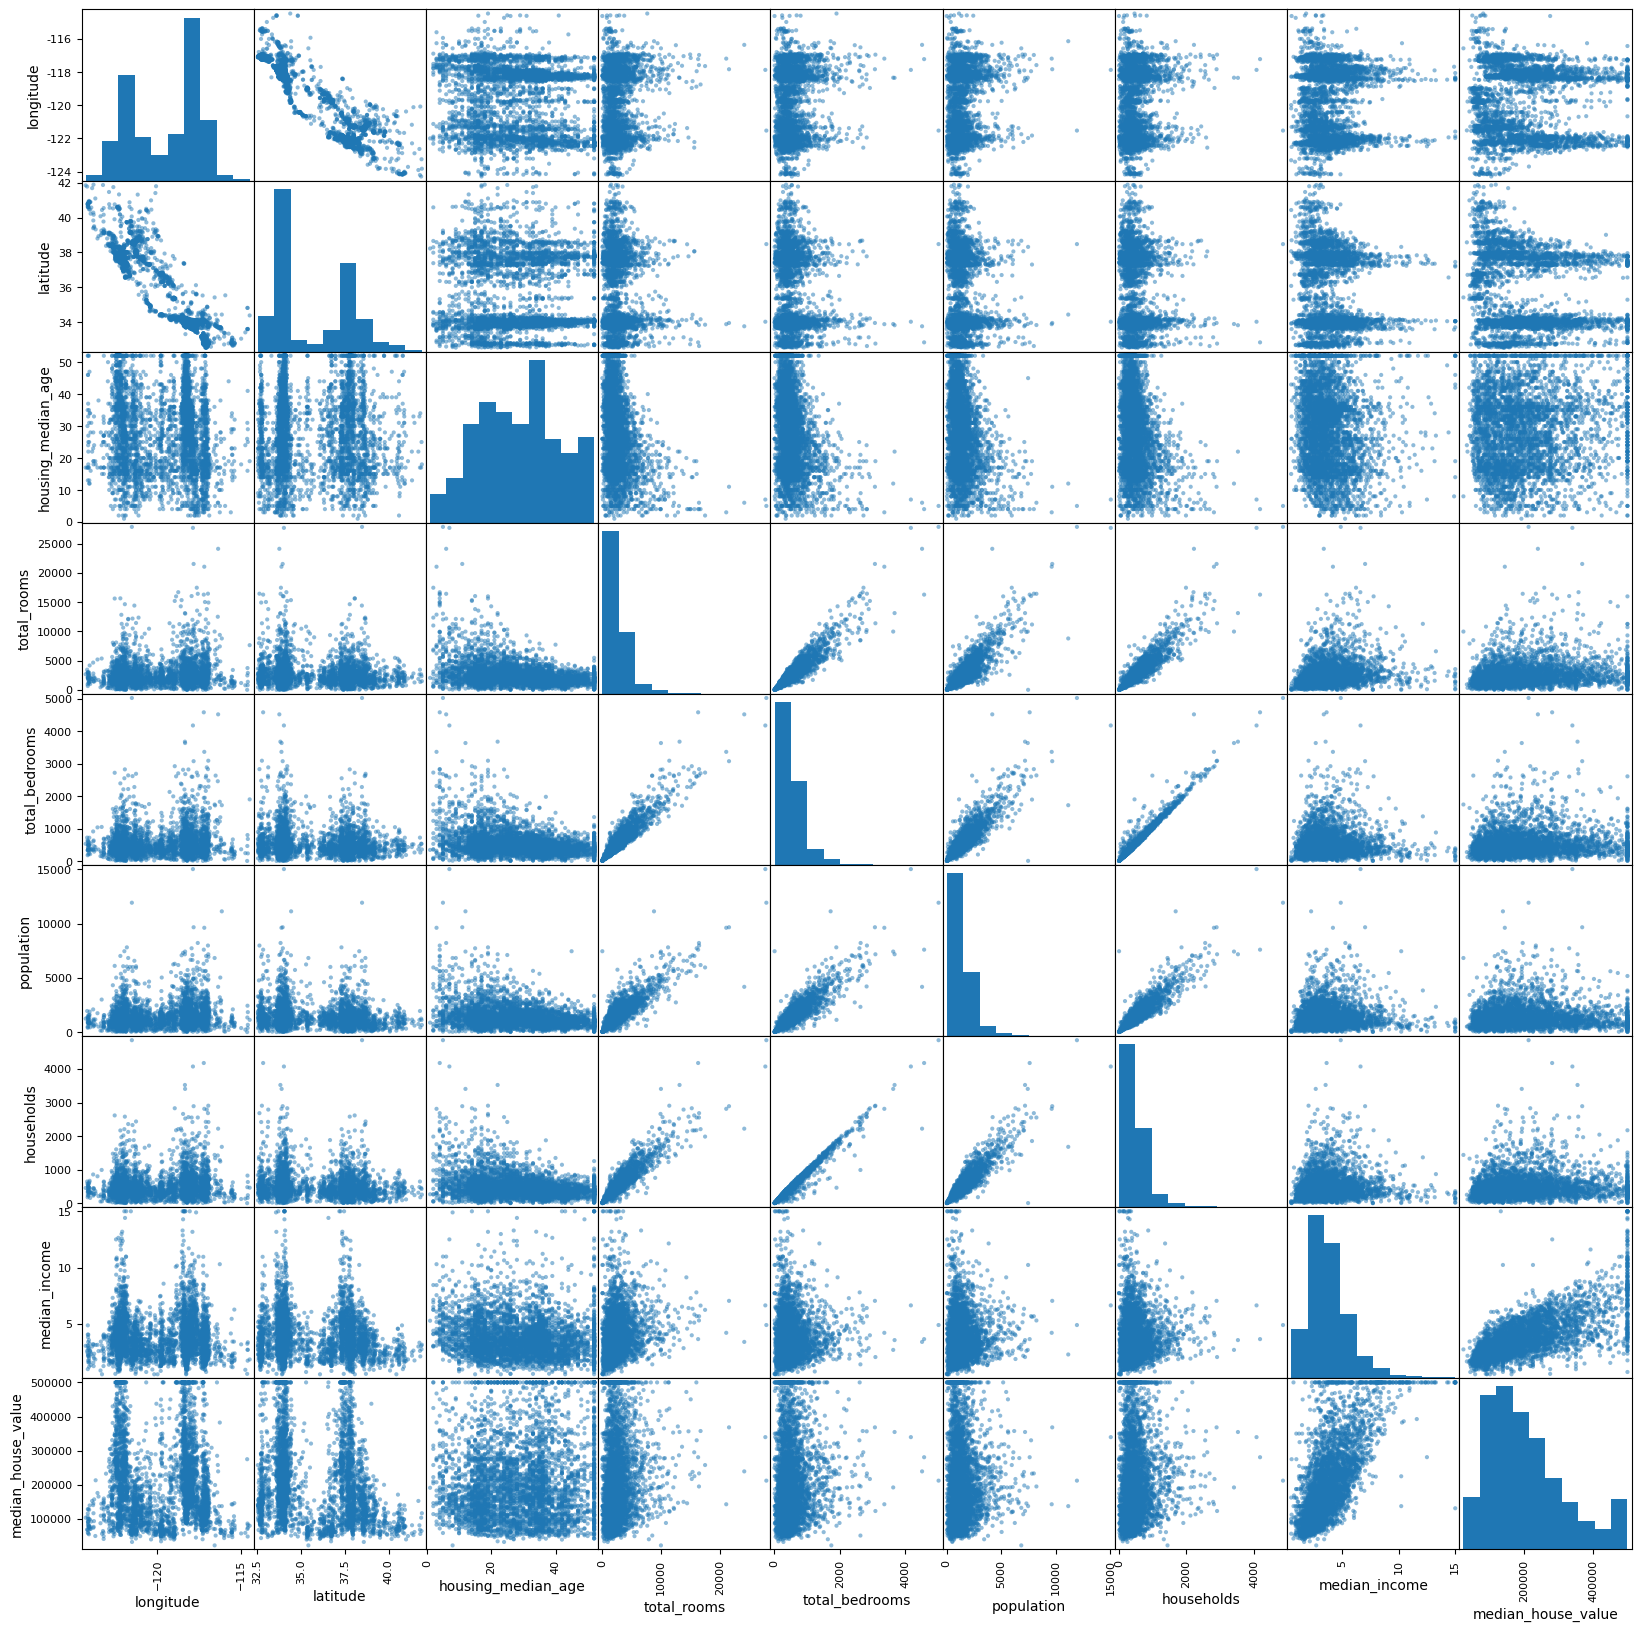

In [13]:
from pandas.plotting import scatter_matrix
lst =[]
for cols in train_data.columns:
    if ((train_data[cols].dtype == 'int64') or (train_data[cols].dtype =='float64')):
        lst.append(cols)
lst

scatter_matrix(train_data[lst],figsize=(20,20))


In [14]:
from sklearn.impute import SimpleImputer
imputer  = SimpleImputer(strategy='median')
housing_missing = train_data.drop(columns=['ocean_proximity'])
housing = housing_missing.select_dtypes (include=[np.number])
imputer.fit(housing)
x = imputer.transform(housing)
housing_df = pd.DataFrame(x,columns=housing_missing.columns,index = housing_missing.index)
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
914,-121.99,37.53,25.0,5405.0,939.0,2831.0,923.0,5.0423,222200.0
1142,-121.60,39.68,15.0,1677.0,345.0,844.0,330.0,2.3958,111200.0
603,-122.07,37.69,29.0,2304.0,618.0,1021.0,552.0,2.5362,203800.0
2767,-115.99,33.40,15.0,1945.0,536.0,515.0,273.0,2.0109,54300.0
16704,-120.56,35.07,14.0,6788.0,1216.0,2866.0,1036.0,3.3603,280200.0
...,...,...,...,...,...,...,...,...,...
10207,-117.92,33.88,52.0,1270.0,276.0,609.0,211.0,3.7500,232500.0
12811,-121.52,38.65,17.0,1269.0,233.0,494.0,231.0,3.9615,331300.0
20546,-121.77,38.69,47.0,1697.0,318.0,775.0,276.0,3.4559,123100.0
5493,-118.46,33.97,19.0,2461.0,521.0,777.0,447.0,10.0000,500001.0


In [15]:
from sklearn.preprocessing import OneHotEncoder
ocean_proximity = train_data[['ocean_proximity']]
type(ocean_proximity)

pandas.core.frame.DataFrame

In [16]:
# OneHatEncoder takes dataframe as an Input
onehatencode = OneHotEncoder()
ocean_catencode = onehatencode.fit_transform(ocean_proximity)

In [17]:
ocean_catencode.toarray()

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(4128, 5))

In [18]:
onehatencode.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [19]:
ocean_catencode = pd.DataFrame(ocean_catencode.toarray(),columns=['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],index= train_data.index )

In [20]:
train_data= pd.concat([train_data,ocean_catencode],axis=1)
train_data.sample(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
10641,-117.80,33.69,13.0,1161.0,289.0,630.0,296.0,3.3438,333300.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
3309,-122.63,38.94,25.0,661.0,144.0,192.0,93.0,1.7566,49000.0,INLAND,0.0,1.0,0.0,0.0,0.0
4723,-118.37,34.05,41.0,2369.0,544.0,1252.0,522.0,2.9883,296100.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
4857,-118.30,34.02,49.0,2120.0,483.0,1522.0,416.0,1.8500,116800.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
5767,-118.29,34.16,35.0,1257.0,318.0,764.0,319.0,3.2083,238000.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
5621,-118.24,33.78,24.0,574.0,173.0,784.0,162.0,2.2500,152300.0,NEAR OCEAN,0.0,0.0,0.0,0.0,1.0
13923,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,INLAND,0.0,1.0,0.0,0.0,0.0
10232,-117.93,33.87,29.0,1221.0,371.0,1822.0,326.0,1.7935,162500.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0
16367,-121.32,38.02,23.0,3251.0,689.0,1890.0,668.0,3.0729,104800.0,INLAND,0.0,1.0,0.0,0.0,0.0
11177,-117.96,33.83,18.0,2067.0,770.0,870.0,541.0,3.1315,137500.0,<1H OCEAN,1.0,0.0,0.0,0.0,0.0


In [21]:
train_data = train_data.drop(columns=['ocean_proximity'],axis = 1)

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1,1))

In [23]:
train_scaled = scaler.fit_transform(train_data)

In [24]:
train_scaled = pd.DataFrame(train_scaled,columns=train_data.columns,index = train_data.index)

In [25]:
train_scaled.sample(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
16337,-0.401831,0.175966,-0.686275,-0.845684,-0.853901,-0.829031,-0.856554,-0.375374,-0.473509,-1.0,1.0,-1.0,-1.0,-1.0
5366,0.202442,-0.682403,0.686275,-0.866796,-0.887341,-0.916179,-0.884584,-0.297223,0.837902,1.0,-1.0,-1.0,-1.0,-1.0
1290,-0.489318,0.167382,0.294118,-0.779405,-0.765127,-0.789383,-0.767931,-0.570778,-0.571938,-1.0,1.0,-1.0,-1.0,-1.0
3109,0.346897,-0.347639,-0.568627,-0.880799,-0.905255,-0.898882,-0.885408,-0.234038,-0.663666,-1.0,1.0,-1.0,-1.0,-1.0
4172,0.234995,-0.669528,0.450980,-0.925822,-0.902070,-0.894359,-0.906843,-0.694887,-0.491938,1.0,-1.0,-1.0,-1.0,-1.0
888,-0.519837,0.072961,-0.450980,-0.593853,-0.703424,-0.679750,-0.706925,0.089599,0.760834,1.0,-1.0,-1.0,-1.0,-1.0
16516,-0.371312,0.126609,-0.333333,-0.828666,-0.802946,-0.796966,-0.792663,-0.655853,-0.573613,-1.0,1.0,-1.0,-1.0,-1.0
2659,-0.906409,0.656652,0.058824,-0.799584,-0.760350,-0.855242,-0.820692,-0.779824,-0.784294,1.0,-1.0,-1.0,-1.0,-1.0
5434,0.196338,-0.688841,0.254902,-0.805185,-0.788217,-0.830362,-0.791014,-0.419539,0.665337,1.0,-1.0,-1.0,-1.0,-1.0
7911,0.267548,-0.714592,0.215686,-0.870674,-0.847532,-0.777275,-0.852844,-0.578447,-0.482724,1.0,-1.0,-1.0,-1.0,-1.0


In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [27]:
train_standard = scaler.fit_transform(train_data)

In [28]:
train_standard = pd.DataFrame(train_standard,columns=train_data.columns,index = train_data.index)
train_standard.sample(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
18340,-1.257520,0.830055,1.864034,-0.324014,-0.552645,-0.671255,-0.548605,2.291829,2.534786,-0.904268,-0.664714,-0.015566,2.823812,-0.390009
20113,0.007752,1.066785,-0.941951,-1.074705,-0.982700,-1.271236,-1.276365,-0.201329,-0.606709,-0.904268,1.504407,-0.015566,-0.354131,-0.390009
14089,1.218869,-1.337651,0.180443,-0.160065,0.029620,-0.288012,0.155163,-0.253849,-0.026943,-0.904268,-0.664714,-0.015566,-0.354131,2.564042
11599,0.736391,-0.859549,0.180443,0.750347,0.193911,0.257087,0.331105,1.438993,1.322380,1.105866,-0.664714,-0.015566,-0.354131,-0.390009
20635,-0.740580,1.781617,-0.300583,-0.455080,-0.393187,-0.532655,-0.449971,-1.205727,-1.121480,-0.904268,1.504407,-0.015566,-0.354131,-0.390009
4705,0.613310,-0.734221,1.864034,-0.265293,-0.289297,-0.550329,-0.324679,-0.168993,1.633495,1.105866,-0.664714,-0.015566,-0.354131,-0.390009
18046,-1.188595,0.737219,0.581298,0.261788,-0.257888,-0.170806,-0.156734,2.711154,2.534786,1.105866,-0.664714,-0.015566,-0.354131,-0.390009
7619,0.662543,-0.840982,-0.541096,2.224012,2.005939,3.072811,2.247805,0.506777,0.048453,1.105866,-0.664714,-0.015566,-0.354131,-0.390009
10776,0.829933,-0.924534,0.100272,-0.205632,-0.122590,-0.266617,-0.103419,0.282355,0.561490,1.105866,-0.664714,-0.015566,-0.354131,-0.390009
6638,0.711775,-0.692445,1.864034,-1.046049,-0.910219,-1.107520,-0.935144,-1.229040,-0.173401,1.105866,-0.664714,-0.015566,-0.354131,-0.390009
